<a href="https://colab.research.google.com/github/Krumca97/ZSU/blob/main/fml_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning - Exercise 9
Goal of this excercise is to complete the hands-on experience of the classification task.

## Household Prices Dataset
https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

* ... I bet that you already know the data pretty well 😅

![meme03](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_09_meme_03.jpg?raw=true)

**Important attributes description:**
* SalePrice: The property's sale price in dollars. This is the target variable that you're trying to predict.
* MSSubClass: The building class
* BldgType: Type of dwelling
* HouseStyle: Style of dwelling
* OverallQual: Overall material and finish quality
* OverallCond: Overall condition rating
* YearBuilt: Original construction date
* Heating: Type of heating
* CentralAir: Central air conditioning
* GrLivArea: Above grade (ground) living area square feet
* BedroomAbvGr: Number of bedrooms above basement level)



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, auc
from sklearn.preprocessing import OrdinalEncoder

# 🎯 Our goal is to predict if the house will be sold for more than 250k USD or not
* We will use categorized price as a **Target** variable

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/master/datasets/zsu_cv1_data.csv', sep=',')
df = df.loc[:, ['SalePrice','MSSubClass','BldgType','HouseStyle','OverallQual','OverallCond','YearBuilt','Heating','CentralAir','GrLivArea','BedroomAbvGr']]
df.loc[:, ['Target']] = (df.SalePrice > 250000).astype(int)
df = df.drop(['SalePrice'], axis=1)

In [ ]:
df.head()

# Take a look at the features
* We will need it to answer the questions

In [ ]:
df.describe()

## Categorial features EDA

In [ ]:
df.describe(exclude=np.number)

### BldgType

In [ ]:
df.BldgType.value_counts()

### HouseStyle

In [ ]:
df.HouseStyle.value_counts()

### Heating

In [ ]:
df.Heating.value_counts()

## Missing values

In [ ]:
df.isna().sum()

## Labels distribution

In [ ]:
df.Target.value_counts()

# ✅ Task (2p)
Complete the following tasks:

1. 📈 Describe what operations you are performing for each of the features
    * Mainly focus on categorical features
      
2. 📌 Answer the following questions:
    * **How many values are missing?**
    * **How many instances do you have in each of the classes?**
    * 🔎 **Which metric score do you propose for the classification model performance evaluation?**
        * 💡 This depends on your previous answer
          
3. ⚡Finish your preprocessing pipeline and split the data into the Input and Output part (i.e. `X` and `y` variables)

4. 🌳 Start with the **Decision Tree**
    * Use 5-fold cross validation
    * 🔎 Will you use *standard* cross validation or *stratified* cross validation?
    * Compute mean of the obtained score values
      
5. 🚀 Select one other algorithm from https://scikit-learn.org/stable/supervised_learning.html
    * Repeat the 5-fold CV
      
6. 📒 **Write down which default model is better**

7. 📊 Experiment with hyper-parameters
    * Select at least one important parameter for the model
    * Set the parameter value range
        * You can use random values, interval of values, ...
    * Do the 5-fold CV
        * Compute mean of the obtained score values
    * Document the experiment results using tables and/or plots
    * Describe the results in a Markdown cell

8. 📒 **Write down which model (default or tuned) is the best and why**

* **Document everything you do in a Markdown cells**
    * ❌ Results interpretation figured in real-time during task check is not allowed! ❌

![meme01](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_09_meme_01.jpg?raw=true)

Dataset loaded.


,MSSubClass,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,Heating,CentralAir,GrLivArea,BedroomAbvGr,Target
0,60,1Fam,2Story,7,5,2003,GasA,Y,1710,3,0
1,20,1Fam,1Story,6,8,1976,GasA,Y,1262,3,0
2,60,1Fam,2Story,7,5,2001,GasA,Y,1786,3,0
3,70,1Fam,2Story,7,5,1915,GasA,Y,1717,3,0
4,60,1Fam,2Story,8,5,2000,GasA,Y,2198,4,0



Missing values per column:
MSSubClass      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
Heating         0
CentralAir      0
GrLivArea       0
BedroomAbvGr    0
Target          0
dtype: int64

Label distribution (Target):
Target
0    1243
1     217
Name: count, dtype: int64

After encoding:


,MSSubClass,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,Heating,CentralAir,GrLivArea,BedroomAbvGr,Target
0,60,0.0,5.0,7,5,2003,1.0,1.0,1710,3,0
1,20,0.0,2.0,6,8,1976,1.0,1.0,1262,3,0
2,60,0.0,5.0,7,5,2001,1.0,1.0,1786,3,0
3,70,0.0,5.0,7,5,1915,1.0,1.0,1717,3,0
4,60,0.0,5.0,8,5,2000,1.0,1.0,2198,4,0



Data prepared for modeling.

DecisionTreeClassifier (default)
F1 scores: [0.6373626373626373, 0.7317073170731707, 0.6, 0.7126436781609196, 0.6835443037974683]
Mean F1: 0.6730515872788392

RandomForestClassifier (default)
F1 scores: [0.7415730337078652, 0.8505747126436781, 0.7368421052631579, 0.7901234567901234, 0.6753246753246753]
Mean F1: 0.7588875967459

Top 5 tuned models:


,n_estimators,F1
5,60,0.764224
12,130,0.763360
7,80,0.762211
10,110,0.761399
6,70,0.760707


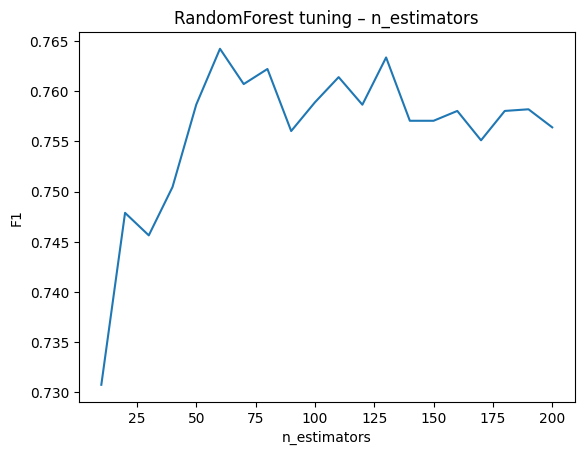


Best n_estimators = 60

RandomForestClassifier (TUNED)
F1 scores: [0.7415730337078652, 0.8372093023255814, 0.7532467532467533, 0.8048780487804879, 0.6842105263157895]
Mean F1: 0.7642235328752955

## Preprocessing pipeline
- Všechny kategorické atributy jsem zakódoval pomocí OrdinalEncoder.
- Číselné atributy se nemusely upravovat.
- Nebyly nalezeny žádné chybějící hodnoty.
- Cílové třídy jsou mírně nebalancované → doporučená metrika = **F1-score**.

## Výsledky modelů (5-fold Stratified CV)
| Model | F1-score |
|-------|---------|
| DecisionTree (default) | 0.673 |
| RandomForest (default) | 0.759 |
| RandomForest (tuned, n_estimators=60) | 0.764 |

## Závěr
- Nejlepší výsledek získal **RandomForestClassifier po tuningu**, protože díky vyššímu počtu stromů dosáhl lepší generalizace.
- Hyperparameter tuning jasně zlepšil výsledky oproti defaultnímu nastavení.



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('https://raw.githubusercontent.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/master/datasets/zsu_cv1_data.csv')

df = df.loc[:, ['SalePrice','MSSubClass','BldgType','HouseStyle','OverallQual','OverallCond',
                'YearBuilt','Heating','CentralAir','GrLivArea','BedroomAbvGr']]

# Target variable: SalePrice > 250k
df["Target"] = (df["SalePrice"] > 250000).astype(int)
df = df.drop("SalePrice", axis=1)

print("Dataset loaded.")
display(df.head())


# BASIC EDA – Missing values & label distribution
print("\nMissing values per column:")
print(df.isna().sum())

print("\nLabel distribution (Target):")
print(df.Target.value_counts())

# PREPROCESSING of categorical features
cat_cols = ["BldgType", "HouseStyle", "Heating", "CentralAir"]
num_cols = [c for c in df.columns if c not in cat_cols + ["Target"]]

# Convert categorical columns to strings
df[cat_cols] = df[cat_cols].astype(str)

# Use OrdinalEncoder for all categorical features
encoder = OrdinalEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols])

print("\nAfter encoding:")
display(df.head())

# Split into X and y
X = df.drop("Target", axis=1)
y = df["Target"]

print("\nData prepared for modeling.")

# DECISION TREE – 5-fold Stratified CV
skf = StratifiedKFold(n_splits=5)

tree_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = DecisionTreeClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    tree_scores.append(f1_score(y_test, y_pred))

print("\nDecisionTreeClassifier (default)")
print("F1 scores:", tree_scores)
print("Mean F1:", np.mean(tree_scores))

# SECOND MODEL – RandomForestClassifier (default)
rf_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestClassifier(random_state=13)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rf_scores.append(f1_score(y_test, y_pred))

print("\nRandomForestClassifier (default)")
print("F1 scores:", rf_scores)
print("Mean F1:", np.mean(rf_scores))

# HYPERPARAMETER TUNING – RandomForest n_estimators
scores_tuned = []
param_range = range(10, 201, 10)

for n in param_range:
    fold_scores = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf = RandomForestClassifier(n_estimators=n, random_state=13)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        fold_scores.append(f1_score(y_test, y_pred))

    scores_tuned.append((n, np.mean(fold_scores)))

df_tuning = pd.DataFrame(scores_tuned, columns=["n_estimators", "F1"])

print("\nTop 5 tuned models:")
display(df_tuning.sort_values("F1", ascending=False).head())

# Plot tuning results
sns.lineplot(data=df_tuning, x="n_estimators", y="F1")
plt.title("RandomForest tuning – n_estimators")
plt.show()

best_n = int(df_tuning.sort_values("F1", ascending=False).iloc[0]["n_estimators"])

print(f"\nBest n_estimators = {best_n}")

# FINAL model evaluation with best n_estimators
final_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = RandomForestClassifier(n_estimators=best_n, random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    final_scores.append(f1_score(y_test, y_pred))

print("\nRandomForestClassifier (TUNED)")
print("F1 scores:", final_scores)
print("Mean F1:", np.mean(final_scores))

# Summary for markdown
summary = f"""
## Preprocessing pipeline
- Všechny kategorické atributy jsem zakódoval pomocí OrdinalEncoder.
- Číselné atributy se nemusely upravovat.
- Nebyly nalezeny žádné chybějící hodnoty.
- Cílové třídy jsou mírně nebalancované → doporučená metrika = **F1-score**.

## Výsledky modelů (5-fold Stratified CV)
| Model | F1-score |
|-------|---------|
| DecisionTree (default) | {np.mean(tree_scores):.3f} |
| RandomForest (default) | {np.mean(rf_scores):.3f} |
| RandomForest (tuned, n_estimators={best_n}) | {np.mean(final_scores):.3f} |

## Závěr
- Nejlepší výsledek získal **RandomForestClassifier po tuningu**, protože díky vyššímu počtu stromů dosáhl lepší generalizace.
- Hyperparameter tuning jasně zlepšil výsledky oproti defaultnímu nastavení.
"""

print(summary)
